<a href="https://colab.research.google.com/github/drskprabhakar/AI-ML-DL-colab-notebooks-coding-models/blob/main/AKARlogmar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np


In [ ]:
df =pd.read_excel('/content/drive/MyDrive/New AK and AR 1wk^J 6wk and 3 months 101125.xlsx')



In [ ]:
sheets=pd.ExcelFile('/content/drive/MyDrive/New AK and AR 1wk^J 6wk and 3 months 101125.xlsx')
sheets.sheet_names

['raw data', 'data 1wk, 6wk and 3 months', 'Sheet1']

In [ ]:
df1=sheets.parse('data 1wk, 6wk and 3 months')


In [ ]:
df1.columns

Index(['PreopR1', 'PreopR2', 'PreopA1', 'PreopVA', 'Unnamed: 4', 'Unnamed: 5',
       'preopVA-logmar', 'POD 1wkVA', 'Unnamed: 8', 'Unnamed: 9', 'logmar1wk',
       'Sph1wk', 'Cyl1wk', 'Axis1wk', 'POD 6wkVA', 'Unnamed: 15',
       'Unnamed: 16', 'logmar6wk', 'Sph6wk ', 'Cyl6wk', 'Axis6wk',
       'POD 3mthVA', 'Unnamed: 22', 'Unnamed: 23', 'logmar3mth', 'Sph3mth',
       'Cyl3mth', 'Axis3mth'],
      dtype='object')

In [ ]:
logmardata = df1[['preopVA-logmar', 'logmar1wk', 'logmar6wk', 'logmar3mth']]
logmardata

,preopVA-logmar,logmar1wk,logmar6wk,logmar3mth
0,0.602060,0.301030,0.30103,0.176091
1,2.300000,0.477121,0.477121,0.301030
2,1.000000,0.602060,0.60206,NaN
3,1.778151,0.477121,0.477121,0.176091
4,0.778151,0.301030,0.30103,NaN
...,...,...,...,...
169,0.778151,0.477121,0.30103,0.301030
170,1.778151,0.477121,0.176091,0.176091
171,0.477121,0.778151,0.477121,NaN
172,0.778151,0.477121,0.30103,NaN


In [ ]:
logmardata.columns

Index(['preopVA-logmar', 'logmar1wk', 'logmar6wk', 'logmar3mth'], dtype='object')

In [ ]:
logmardata.isnull().sum()

,0
preopVA-logmar,0
logmar1wk,0
logmar6wk,0
logmar3mth,62


In [ ]:
logmardata.dropna(inplace=True)
logmardata.isnull().sum()

,0
preopVA-logmar,0
logmar1wk,0
logmar6wk,0
logmar3mth,0


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

# Assuming your DataFrame is named logmardata
cols = ['preopVA-logmar', 'logmar1wk', 'logmar6wk', 'logmar3mth']

# Create an empty list to collect results
results = []

for col in cols:
    data = logmardata[col].dropna()
    n = len(data)
    mean = data.mean()
    sd = data.std(ddof=1)
    sem = sd / np.sqrt(n)
    skew = stats.skew(data)
    kurt = stats.kurtosis(data)

    # 95% CI for the mean using t-distribution
    ci_low, ci_high = stats.t.interval(0.95, df=n-1, loc=mean, scale=sem)

    results.append({
        'Variable': col,
        'Mean': round(mean, 3),
        'SD': round(sd, 3),
        'SEM': round(sem, 3),
        'Skewness': round(skew, 3),
        'Kurtosis': round(kurt, 3),
        '95% CI Lower': round(ci_low, 3),
        '95% CI Upper': round(ci_high, 3)
    })

# Convert results into a DataFrame
desc_stats = pd.DataFrame(results).set_index('Variable')

print(desc_stats)


                 Mean     SD    SEM  Skewness  Kurtosis  95% CI Lower  \
Variable                                                                
preopVA-logmar  1.458  0.654  0.062     0.086    -1.127         1.335   
logmar1wk       0.429  0.247  0.023     1.927     7.573         0.383   
logmar6wk       0.275  0.175  0.017     0.778     0.449         0.242   
logmar3mth      0.218  0.146  0.014     0.756     0.733         0.190   

                95% CI Upper  
Variable                      
preopVA-logmar         1.580  
logmar1wk              0.476  
logmar6wk              0.307  
logmar3mth             0.245  


In [ ]:
# Format descriptive statistics for reporting
desc_stats['Formatted'] = (
    desc_stats['Mean'].astype(str) + " ± " + desc_stats['SD'].astype(str) +
    " (" + desc_stats['95% CI Lower'].astype(str) + "–" + desc_stats['95% CI Upper'].astype(str) + ")"
)

# Display concise journal-style table
print(desc_stats[['Formatted']])


                                  Formatted
Variable                                   
preopVA-logmar   1.458 ± 0.654 (1.335–1.58)
logmar1wk       0.429 ± 0.247 (0.383–0.476)
logmar6wk       0.275 ± 0.175 (0.242–0.307)
logmar3mth       0.218 ± 0.146 (0.19–0.245)


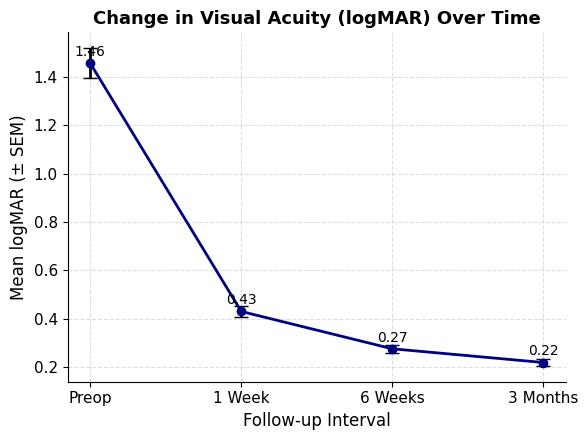

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define your columns and compute stats
timepoints = ['preopVA-logmar', 'logmar1wk', 'logmar6wk', 'logmar3mth']
labels = ['Preop', '1 Week', '6 Weeks', '3 Months']

means = [logmardata[col].mean() for col in timepoints]
sems = [logmardata[col].sem() for col in timepoints]

# --- Figure setup ---
plt.figure(figsize=(6, 4.5))
plt.errorbar(
    labels, means, yerr=sems, fmt='o-',
    capsize=5, linewidth=2, markersize=6,
    ecolor='black', color='navy'
)

# --- Aesthetic enhancements for journal style ---
plt.title("Change in Visual Acuity (logMAR) Over Time", fontsize=13, weight='bold')
plt.ylabel("Mean logMAR (± SEM)", fontsize=12)
plt.xlabel("Follow-up Interval", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)

# Tick and spine adjustments
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)

# Annotate mean values above points
for i, (x, y) in enumerate(zip(labels, means)):
    plt.text(i, y + 0.03, f"{y:.2f}", ha='center', fontsize=10)

# Tight layout for clean edges
plt.tight_layout()

plt.show()


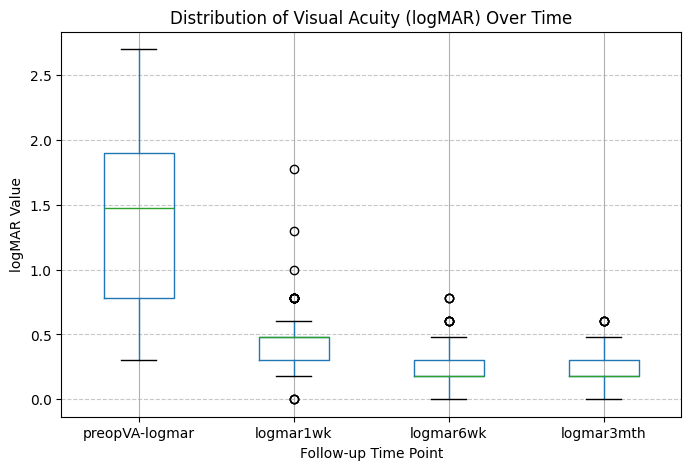

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
logmardata.boxplot(column=['preopVA-logmar', 'logmar1wk', 'logmar6wk', 'logmar3mth'])
plt.title("Distribution of Visual Acuity (logMAR) Over Time")
plt.ylabel("logMAR Value")
plt.xlabel("Follow-up Time Point")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


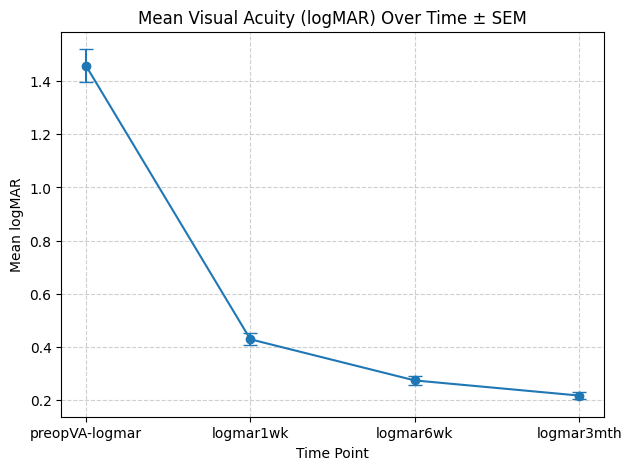

In [ ]:
timepoints = ['preopVA-logmar', 'logmar1wk', 'logmar6wk', 'logmar3mth']

means = [logmardata[col].mean() for col in timepoints]
sems = [logmardata[col].sem() for col in timepoints]

plt.figure(figsize=(7, 5))
plt.errorbar(timepoints, means, yerr=sems, fmt='-o', capsize=5)
plt.title("Mean Visual Acuity (logMAR) Over Time ± SEM")
plt.ylabel("Mean logMAR")
plt.xlabel("Time Point")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


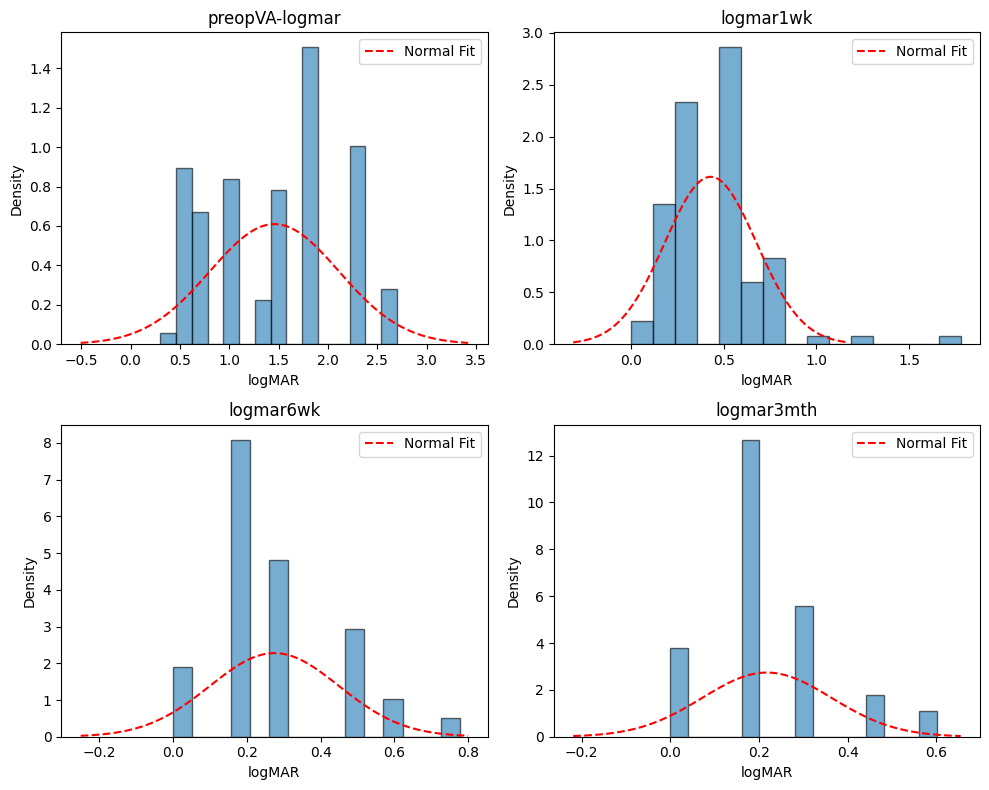

In [ ]:
from scipy.stats import norm

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, col in enumerate(timepoints):
    data = logmardata[col].dropna()
    mean, sd = data.mean(), data.std()
    axes[i].hist(data, bins=15, density=True, alpha=0.6, edgecolor='black')

    # Add normal curve
    x = np.linspace(mean - 3*sd, mean + 3*sd, 100)
    axes[i].plot(x, norm.pdf(x, mean, sd), 'r--', label='Normal Fit')

    axes[i].set_title(col)
    axes[i].legend()
    axes[i].set_xlabel('logMAR')
    axes[i].set_ylabel('Density')

plt.tight_layout()
plt.show()


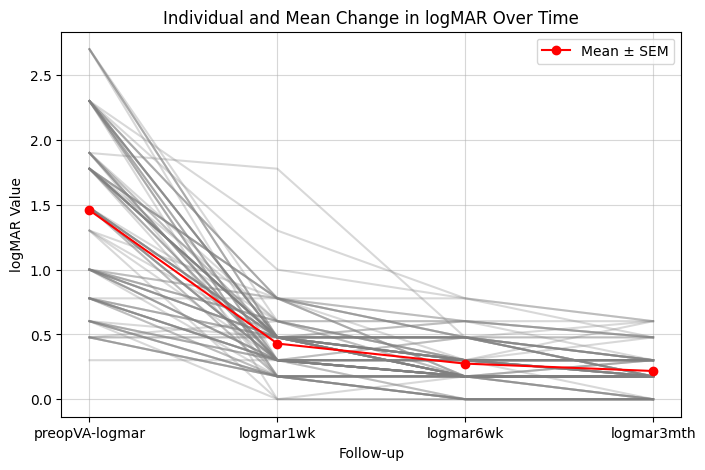

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(logmardata[['preopVA-logmar', 'logmar1wk', 'logmar6wk', 'logmar3mth']].T, color='gray', alpha=0.3)
plt.plot(timepoints, [logmardata[col].mean() for col in timepoints], 'o-', color='red', label='Mean ± SEM')
plt.title("Individual and Mean Change in logMAR Over Time")
plt.ylabel("logMAR Value")
plt.xlabel("Follow-up")
plt.grid(alpha=0.5)
plt.legend()
plt.show()


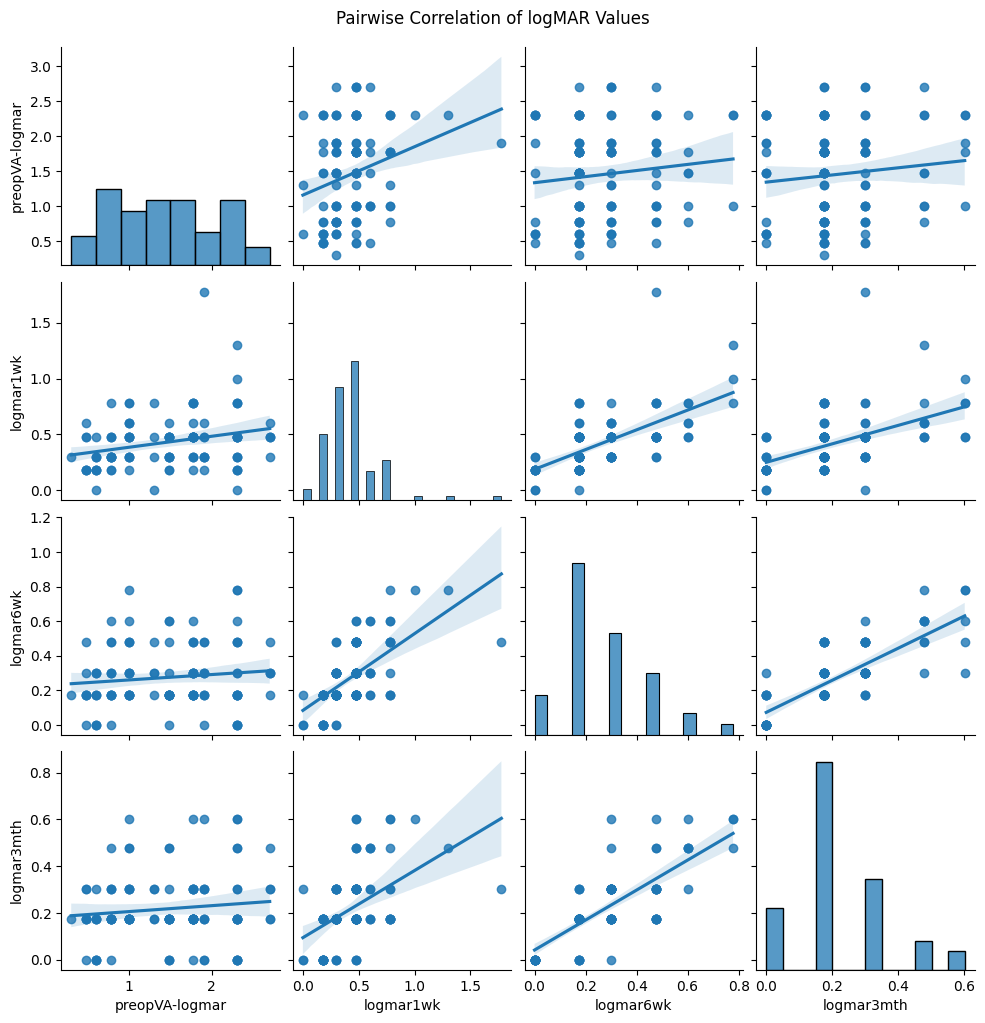

                preopVA-logmar  logmar1wk  logmar6wk  logmar3mth
preopVA-logmar           1.000      0.261      0.117       0.114
logmar1wk                0.261      1.000      0.626       0.487
logmar6wk                0.117      0.626      1.000       0.771
logmar3mth               0.114      0.487      0.771       1.000


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(logmardata, kind='reg')
plt.suptitle("Pairwise Correlation of logMAR Values", y=1.02)
plt.show()

print(logmardata.corr().round(3))


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

X = logmardata[['preopVA-logmar', 'logmar1wk', 'logmar6wk']]
y = logmardata['logmar3mth']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = sm.OLS(y_train, sm.add_constant(X_train)).fit()
y_pred = model.predict(sm.add_constant(X_test))

print("Test R²:", round(r2_score(y_test, y_pred), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred)), 3))


Test R²: 0.725
RMSE: 0.065


In [ ]:
import statsmodels.api as sm

X = logmardata[['preopVA-logmar']]
y = logmardata['logmar3mth']

X = sm.add_constant(X)  # Add intercept
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:             logmar3mth   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.445
Date:                Mon, 10 Nov 2025   Prob (F-statistic):              0.232
Time:                        14:42:52   Log-Likelihood:                 58.079
No. Observations:                 112   AIC:                            -112.2
Df Residuals:                     110   BIC:                            -106.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.1808      0.034      5.

In [ ]:
X = logmardata[['preopVA-logmar', 'logmar1wk', 'logmar6wk']]
y = logmardata['logmar3mth']

X = sm.add_constant(X)
model_multi = sm.OLS(y, X).fit()
print(model_multi.summary())


                            OLS Regression Results                            
Dep. Variable:             logmar3mth   R-squared:                       0.594
Model:                            OLS   Adj. R-squared:                  0.583
Method:                 Least Squares   F-statistic:                     52.78
Date:                Mon, 10 Nov 2025   Prob (F-statistic):           4.40e-21
Time:                        14:43:25   Log-Likelihood:                 107.90
No. Observations:                 112   AIC:                            -207.8
Df Residuals:                     108   BIC:                            -196.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.0345      0.025      1.

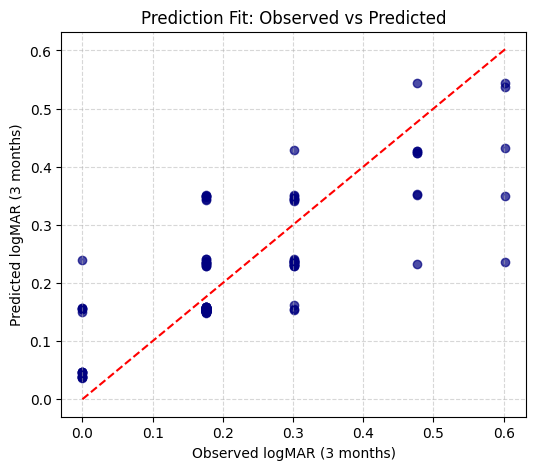

In [ ]:
import numpy as np

pred = model_multi.predict(X)
plt.figure(figsize=(6,5))
plt.scatter(y, pred, color='navy', alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Observed logMAR (3 months)")
plt.ylabel("Predicted logMAR (3 months)")
plt.title("Prediction Fit: Observed vs Predicted")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


In [ ]:
import statsmodels.api as sm
import pandas as pd

# Define predictors and dependent variable
X = logmardata[['preopVA-logmar', 'logmar1wk', 'logmar6wk']].dropna()
y = logmardata.loc[X.index, 'logmar3mth']

# Add constant for intercept
X = sm.add_constant(X)

# Fit OLS model
model = sm.OLS(y, X).fit()

# Extract coefficients and summary statistics
coef_table = pd.DataFrame({
    'Predictor': model.params.index,
    'Coefficient (β)': model.params.values.round(3),
    'Std. Error': model.bse.values.round(3),
    't-Value': model.tvalues.values.round(3),
    'p-Value': model.pvalues.values.round(4)
})

# 95% Confidence Intervals
conf_int = model.conf_int().round(3)
coef_table['95% CI Lower'] = conf_int[0].values
coef_table['95% CI Upper'] = conf_int[1].values

print(coef_table)
print("\nModel R²:", round(model.rsquared, 3),
      " | Adjusted R²:", round(model.rsquared_adj, 3))


        Predictor  Coefficient (β)  Std. Error  t-Value  p-Value  \
0           const            0.035       0.025    1.375   0.1721   
1  preopVA-logmar            0.005       0.014    0.384   0.7015   
2       logmar1wk           -0.000       0.048   -0.005   0.9959   
3       logmar6wk            0.639       0.065    9.752   0.0000   

   95% CI Lower  95% CI Upper  
0        -0.015         0.084  
1        -0.023         0.033  
2        -0.095         0.094  
3         0.509         0.768  

Model R²: 0.594  | Adjusted R²: 0.583


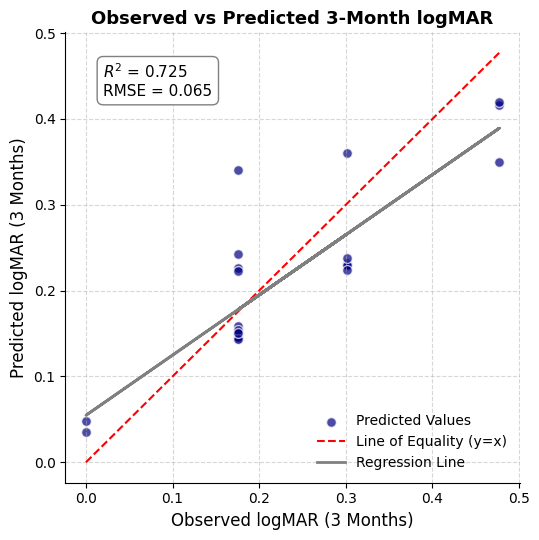

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

# Assuming you already have:
# y_test (actual 3-month logMAR values)
# y_pred (model-predicted values)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

plt.figure(figsize=(5.5, 5.5))

# Scatter plot
plt.scatter(y_test, y_pred, color='navy', alpha=0.7, edgecolor='white', s=50, label='Predicted Values')

# Line of perfect agreement
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', linewidth=1.5, label='Line of Equality (y=x)')

# Regression fit line (optional visual trend)
z = np.polyfit(y_test, y_pred, 1)
p = np.poly1d(z)
plt.plot(y_test, p(y_test), color='gray', linestyle='-', linewidth=2, label='Regression Line')

# Labels and style
plt.xlabel("Observed logMAR (3 Months)", fontsize=12)
plt.ylabel("Predicted logMAR (3 Months)", fontsize=12)
plt.title("Observed vs Predicted 3-Month logMAR", fontsize=13, weight='bold')

# Annotate R² and RMSE
plt.text(lims[0] + 0.02, lims[1] - 0.05,
         f"$R^2$ = {r2:.3f}\nRMSE = {rmse:.3f}",
         fontsize=11, bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.4'))

plt.legend(frameon=False, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

# Remove unnecessary spines for cleaner journal look
for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


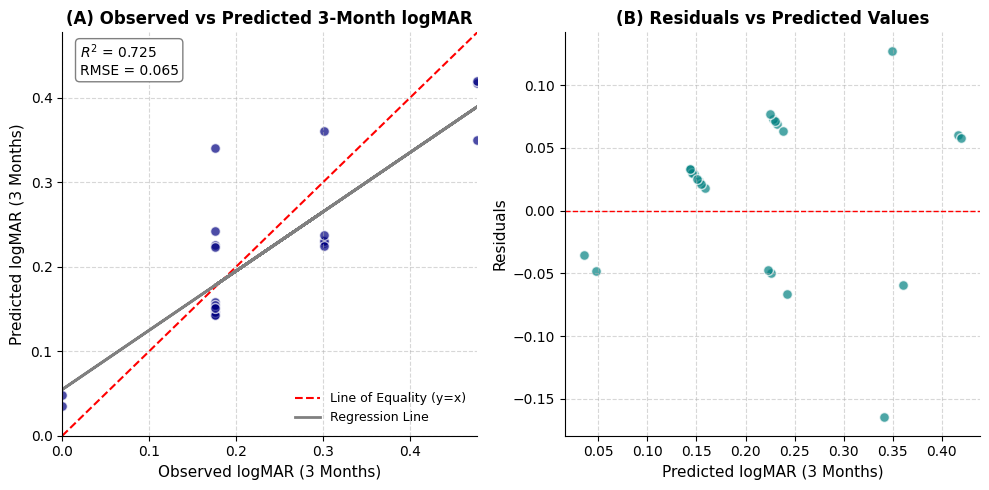

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

# Ensure you already have y_test (actual) and y_pred (predicted)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# ---------- Panel A: Observed vs Predicted ----------
axes[0].scatter(y_test, y_pred, color='navy', alpha=0.7, edgecolor='white', s=50)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Line of Equality (y=x)')
z = np.polyfit(y_test, y_pred, 1)
p = np.poly1d(z)
axes[0].plot(y_test, p(y_test), color='gray', linestyle='-', linewidth=2, label='Regression Line')
axes[0].set_xlim(lims)
axes[0].set_ylim(lims)
axes[0].set_title("(A) Observed vs Predicted 3-Month logMAR", fontsize=12, weight='bold')
axes[0].set_xlabel("Observed logMAR (3 Months)", fontsize=11)
axes[0].set_ylabel("Predicted logMAR (3 Months)", fontsize=11)
axes[0].legend(frameon=False, fontsize=9)
axes[0].grid(True, linestyle='--', alpha=0.5)
for spine in ['top', 'right']:
    axes[0].spines[spine].set_visible(False)
axes[0].text(lims[0]+0.02, lims[1]-0.05,
             f"$R^2$ = {r2:.3f}\nRMSE = {rmse:.3f}",
             fontsize=10, bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3'))

# ---------- Panel B: Residual Plot ----------
axes[1].scatter(y_pred, residuals, color='teal', alpha=0.7, edgecolor='white', s=50)
axes[1].axhline(0, color='r', linestyle='--', linewidth=1)
axes[1].set_title("(B) Residuals vs Predicted Values", fontsize=12, weight='bold')
axes[1].set_xlabel("Predicted logMAR (3 Months)", fontsize=11)
axes[1].set_ylabel("Residuals", fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.5)
for spine in ['top', 'right']:
    axes[1].spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


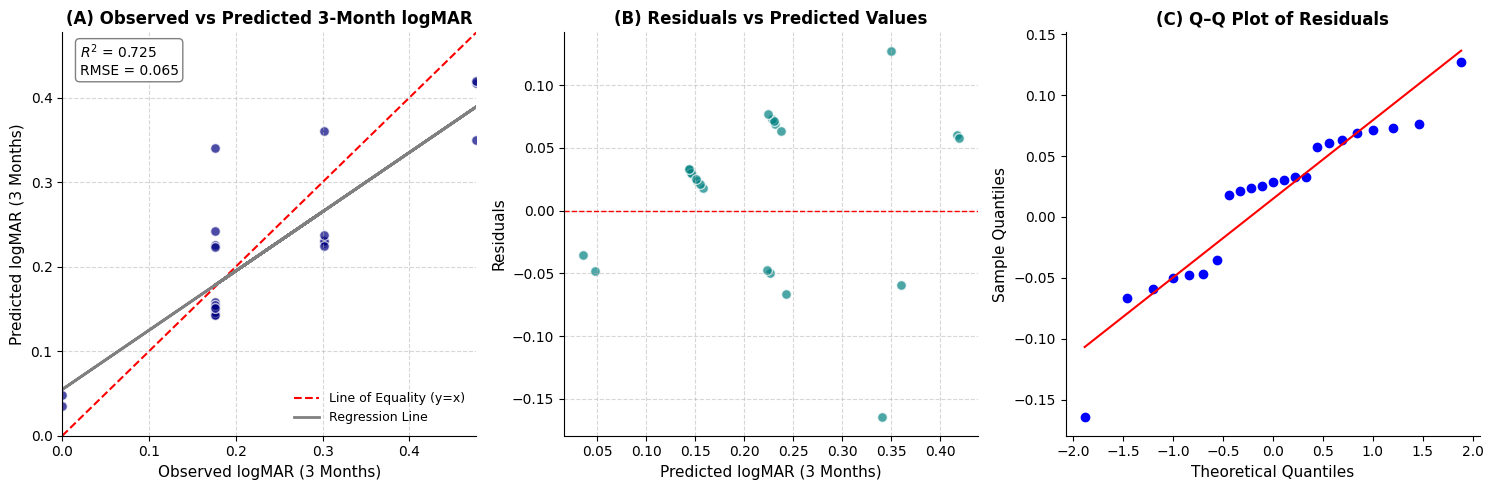

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from sklearn.metrics import r2_score, mean_squared_error

# Ensure y_test (actual) and y_pred (predicted) are defined
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
residuals = y_test - y_pred

# Set up 3 panels side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ---------- Panel A: Observed vs Predicted ----------
axes[0].scatter(y_test, y_pred, color='navy', alpha=0.7, edgecolor='white', s=50)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Line of Equality (y=x)')
z = np.polyfit(y_test, y_pred, 1)
p = np.poly1d(z)
axes[0].plot(y_test, p(y_test), color='gray', linestyle='-', linewidth=2, label='Regression Line')
axes[0].set_xlim(lims)
axes[0].set_ylim(lims)
axes[0].set_title("(A) Observed vs Predicted 3-Month logMAR", fontsize=12, weight='bold')
axes[0].set_xlabel("Observed logMAR (3 Months)", fontsize=11)
axes[0].set_ylabel("Predicted logMAR (3 Months)", fontsize=11)
axes[0].legend(frameon=False, fontsize=9)
axes[0].grid(True, linestyle='--', alpha=0.5)
for spine in ['top', 'right']:
    axes[0].spines[spine].set_visible(False)
axes[0].text(lims[0]+0.02, lims[1]-0.05,
             f"$R^2$ = {r2:.3f}\nRMSE = {rmse:.3f}",
             fontsize=10, bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3'))

# ---------- Panel B: Residuals vs Predicted ----------
axes[1].scatter(y_pred, residuals, color='teal', alpha=0.7, edgecolor='white', s=50)
axes[1].axhline(0, color='r', linestyle='--', linewidth=1)
axes[1].set_title("(B) Residuals vs Predicted Values", fontsize=12, weight='bold')
axes[1].set_xlabel("Predicted logMAR (3 Months)", fontsize=11)
axes[1].set_ylabel("Residuals", fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.5)
for spine in ['top', 'right']:
    axes[1].spines[spine].set_visible(False)

# ---------- Panel C: Q–Q Plot of Residuals ----------
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].get_lines()[1].set_color('red')
axes[2].set_title("(C) Q–Q Plot of Residuals", fontsize=12, weight='bold')
axes[2].set_xlabel("Theoretical Quantiles", fontsize=11)
axes[2].set_ylabel("Sample Quantiles", fontsize=11)
for spine in ['top', 'right']:
    axes[2].spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from scipy.stats import shapiro
import pandas as pd

# Assuming your model was fit as:
# model = sm.OLS(y, X).fit()

# Residuals
residuals = model.resid

# --- 1️⃣ Shapiro–Wilk Test for Normality ---
shapiro_stat, shapiro_p = shapiro(residuals)

# --- 2️⃣ Durbin–Watson Test for Autocorrelation ---
dw_stat = durbin_watson(residuals)

# --- 3️⃣ Variance Inflation Factor (VIF) for Multicollinearity ---
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# --- Summarize results ---
print("\n=== Regression Diagnostic Tests ===")
print(f"Shapiro–Wilk Test (Normality): W = {shapiro_stat:.3f}, p = {shapiro_p:.4f}")
print(f"Durbin–Watson Statistic (Autocorrelation): {dw_stat:.3f}")
print("\nVariance Inflation Factor (VIF):")
print(vif_data)



=== Regression Diagnostic Tests ===
Shapiro–Wilk Test (Normality): W = 0.923, p = 0.0000
Durbin–Watson Statistic (Autocorrelation): 1.848

Variance Inflation Factor (VIF):
         Variable       VIF
0           const  7.992732
1  preopVA-logmar  1.077296
2       logmar1wk  1.748796
3       logmar6wk  1.652105
